<a href="https://colab.research.google.com/github/wcaul10/Machine-Learning-Coursework-2/blob/main/Task-1-CW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import os
from google.colab import drive

# connecting google drive to allow checkpints
drive.mount('/content/drive')
checkpoint_dir = '/content/drive/MyDrive/ML_Coursework_Checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'simclr_resnet18_checkpoint.pth')

# defining simclr augmentations
class SimCLRTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

color_jitter = transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                        transform=SimCLRTransform(train_transform))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=2, drop_last=True)

# defining untrained resnet-18 model
class SimCLR_ResNet18(nn.Module):
    def __init__(self, out_dim=128):
        super(SimCLR_ResNet18, self).__init__()
        # Loading baseline ResNet18 with no pre-trained weights
        self.backbone = torchvision.models.resnet18(weights=None)

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.projection_head = nn.Sequential(
            nn.Linear(num_ftrs, num_ftrs),
            nn.ReLU(),
            nn.Linear(num_ftrs, out_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        projections = self.projection_head(features)
        return features, projections # getting features for K-means later

# simclr contrastive loss
def nt_xent_loss(proj1, proj2, temperature=0.5):
    batch_size = proj1.size(0)
    projections = torch.cat([proj1, proj2], dim=0)
    projections = F.normalize(projections, dim=1)

    # cosine similarity matrix
    similarity_matrix = torch.matmul(projections, projections.T)

    labels = torch.cat([torch.arange(batch_size) for i in range(2)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    labels = labels.to(proj1.device)

    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(proj1.device)
    labels = labels[~mask].view(labels.shape[0], -1)
    similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)

    similarity_matrix = similarity_matrix / temperature

    positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)
    negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)
    logits = torch.cat([positives, negatives], dim=1)

    true_labels = torch.zeros(logits.shape[0], dtype=torch.long).to(proj1.device)
    return F.cross_entropy(logits, true_labels)

# initialise and load checkpoints if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimCLR_ResNet18().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.4, momentum=0.9, weight_decay=1e-4)

start_epoch = 0
if os.path.exists(checkpoint_path):
    print("Loading existing checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")

# training loop
epochs = 100

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0.0

    for (view1, view2), _ in trainloader:
        view1, view2 = view1.to(device), view2.to(device)

        optimizer.zero_grad()
        _, proj1 = model(view1)
        _, proj2 = model(view2)

        loss = nt_xent_loss(proj1, proj2)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

    # save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'loss': loss.item(),
        }, checkpoint_path)
        print("Checkpoint saved!")

print("Training cycle complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading existing checkpoint...
Resuming from epoch 70
Epoch [71/100], Loss: 5.1398
Epoch [72/100], Loss: 5.1386
Epoch [73/100], Loss: 5.1341
Epoch [74/100], Loss: 5.1359
Epoch [75/100], Loss: 5.1370
Checkpoint saved!
Epoch [76/100], Loss: 5.1393
Epoch [77/100], Loss: 5.1340
Epoch [78/100], Loss: 5.1371
Epoch [79/100], Loss: 5.1362
Epoch [80/100], Loss: 5.1338
Checkpoint saved!
Epoch [81/100], Loss: 5.1419
Epoch [82/100], Loss: 5.1324
Epoch [83/100], Loss: 5.1274
Epoch [84/100], Loss: 5.1330
Epoch [85/100], Loss: 5.1302
Checkpoint saved!
Epoch [86/100], Loss: 5.1346
Epoch [87/100], Loss: 5.1300
Epoch [88/100], Loss: 5.1332
Epoch [89/100], Loss: 5.1346
Epoch [90/100], Loss: 5.1337
Checkpoint saved!
Epoch [91/100], Loss: 5.1342
Epoch [92/100], Loss: 5.1235
Epoch [93/100], Loss: 5.1350
Epoch [94/100], Loss: 5.1270
Epoch [95/100], Loss: 5.1274
Checkpoint saved!
Ep

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

# extract embeddings
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings, indices = [], []
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs = inputs.to(device)
            features, _ = model(inputs)
            features = F.normalize(features, dim=1) #L2 normalise
            embeddings.append(features.cpu().numpy())
            indices.append(np.arange(batch_idx * dataloader.batch_size, (batch_idx + 1) * dataloader.batch_size))

    return np.vstack(embeddings), np.concatenate(indices)

# run k-means
def cluster_data(embeddings, num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=42)
    return kmeans.fit_predict(embeddings)

# typicality
def calculate_typicality(cluster_embeddings, K=20):
    actual_k = min(K, len(cluster_embeddings))
    if actual_k < 5: return np.zeros(len(cluster_embeddings))

    nbrs = NearestNeighbors(n_neighbors=actual_k, algorithm='auto').fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)

    avg_distances = np.mean(distances[:, 1:], axis=1)
    return 1.0 / (avg_distances + 1e-8)

# select queries
def typiclust_select(embeddings, cluster_assignments, budget):
    selected_indices = []
    unique_clusters, counts = np.unique(cluster_assignments, return_counts=True)
    sorted_cluster_indices = np.argsort(counts)[::-1] # largest clusters first

    for i in range(budget):
        target_cluster_id = unique_clusters[sorted_cluster_indices[i]]
        points_in_cluster_idx = np.where(cluster_assignments == target_cluster_id)[0]
        cluster_embeddings = embeddings[points_in_cluster_idx]

        typicality_scores = calculate_typicality(cluster_embeddings)
        most_typical_local_idx = np.argmax(typicality_scores)

        selected_indices.append(points_in_cluster_idx[most_typical_local_idx])

    return selected_indices

1. Loading clean CIFAR-10 dataset...
2. Extracting features using your 100-epoch model...
3. Running TypiClust to find the 10 best images...

🎉 TypiClust complete! Plotting selected images...


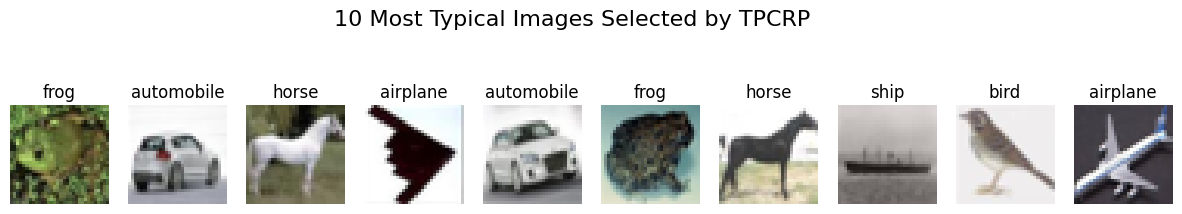

In [ ]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading clean CIFAR-10 dataset...")
standard_transform = transforms.Compose([transforms.ToTensor()])
standard_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=standard_transform)
standard_trainloader = torch.utils.data.DataLoader(standard_trainset, batch_size=256, shuffle=False, num_workers=2)

print("Extracting features using 100-epoch model...")
embeddings, image_indices = extract_embeddings(model, standard_trainloader, device)

budget = 10
print(f"Running TypiClust to find the {budget} best images...")
cluster_assignments = cluster_data(embeddings, num_clusters=budget)
selected_dataset_indices = typiclust_select(embeddings, cluster_assignments, budget)

print("TypiClust complete! Plotting selected images...")

# plotting images
classes = standard_trainset.classes
fig, axes = plt.subplots(1, budget, figsize=(15, 3))
for i, idx in enumerate(selected_dataset_indices):
    img, label = standard_trainset[idx]
    img = img.permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(classes[label])
    axes[i].axis('off')
plt.suptitle("10 Most Typical Images Selected by TPCRP", fontsize=16)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

print("Preparing the Test Set...")
test_transform = transforms.Compose([transforms.ToTensor()])
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print("Extracting features for the Test Set...")
test_embeddings, _ = extract_embeddings(model, testloader, device)
test_labels = np.array(testset.targets)
train_labels = np.array(standard_trainset.targets)

print("Training and Testing Classifiers...")

# --- TEAM TYPICLUST ---
typiclust_X = embeddings[selected_dataset_indices]
typiclust_y = train_labels[selected_dataset_indices]

clf_typiclust = LogisticRegression(max_iter=1000, C=1.0)
try:
    clf_typiclust.fit(typiclust_X, typiclust_y)
    typiclust_accuracy = clf_typiclust.score(test_embeddings, test_labels) * 100
except ValueError:
    typiclust_accuracy = 0.0

# --- TEAM RANDOM (5-Run Average) ---
random_accuracies = []
for run in range(5):
    random_indices = np.random.choice(len(train_labels), size=budget, replace=False)
    random_X = embeddings[random_indices]
    random_y = train_labels[random_indices]

    clf_random = LogisticRegression(max_iter=1000, C=1.0)
    try:
        clf_random.fit(random_X, random_y)
        acc = clf_random.score(test_embeddings, test_labels) * 100
        random_accuracies.append(acc)
    except ValueError:
        pass

avg_random_accuracy = np.mean(random_accuracies) if random_accuracies else 0.0

print("\n" + "="*50)
print("📊 FINAL ACCURACY RESULTS 📊")
print("="*50)
print(f"Random Baseline (5-run avg): {avg_random_accuracy:.2f}%")
print(f"TypiClust (TPC_RP) Accuracy: {typiclust_accuracy:.2f}%")
print("="*50)

1. Preparing the Test Set...
2. Extracting features for the Test Set...

3. Training and Testing Classifiers...

📊 FINAL ACCURACY RESULTS 📊
Random Baseline (5-run avg): 17.31%
TypiClust (TPC_RP) Accuracy: 26.87%
